<a href="https://colab.research.google.com/github/AmanIITM02/pyvisa-vna-automation/blob/main/PyVISA_mock_VNA_frequency_sweep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initiating Microwave Frequency Sweep (4.9 GHz to 5.1 GHz)...
Data acquired. Visual benchmark saved.


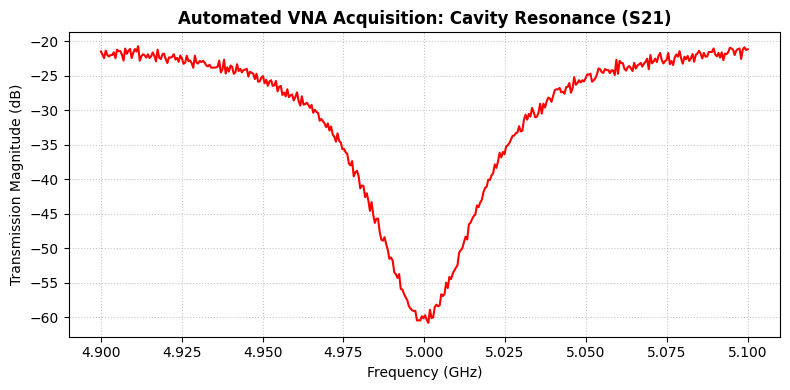

In [5]:
!pip install PyVISA
"""
PyVISA Instrument Controller: Mock Vector Network Analyzer (VNA)
Automates a frequency sweep and data acquisition using SCPI commands.
"""

import numpy as np
import matplotlib.pyplot as plt

# Try to import PyVISA. If physical hardware isn't connected, fallback to mock mode.
try:
    import pyvisa
    rm = pyvisa.ResourceManager()
    # Connect to the VNA via its IP Address (TCPIP protocol)
    vna = rm.open_resource('TCPIP0::192.168.1.100::inst0::INSTR')
    hardware_connected = True
except (ImportError, ValueError, Exception):
    print("WARNING: Physical VNA not found. Running in Hardware Simulation Mode.")
    hardware_connected = False

def acquire_vna_sweep(start_freq, stop_freq, points):
    """Sends SCPI commands to the VNA and retrieves transmission data."""
    if hardware_connected:
        vna.write('*RST') # Reset instrument
        vna.write(f':SENS:FREQ:STAR {start_freq}GHZ')
        vna.write(f':SENS:FREQ:STOP {stop_freq}GHZ')
        vna.write(f':SENS:SWE:POIN {points}')

        # Trigger sweep and read data
        vna.write(':INIT:CONT OFF; :INIT:IMM; *WAI')
        raw_data = vna.query_ascii_values(':CALC:DATA? FDATA')
        return np.linspace(start_freq, stop_freq, points), np.array(raw_data)
    else:
        # Mocking the resonance dip of a 5 GHz cavity for offline portfolio testing
        frequencies = np.linspace(start_freq, stop_freq, points)
        resonance = 5.0
        linewidth = 0.02
        noise = np.random.normal(0, 0.5, points)
        # Lorentzian dip formula mimicking S21 transmission data
        mock_data = -20 - 40 / (1 + ((frequencies - resonance) / linewidth)**2) + noise
        return frequencies, mock_data

# Execute the Sweep
print("Initiating Microwave Frequency Sweep (4.9 GHz to 5.1 GHz)...")
freqs, transmission_db = acquire_vna_sweep(start_freq=4.9, stop_freq=5.1, points=400)

# Generate Benchmark Plot for GitHub README
plt.figure(figsize=(8, 4))
plt.plot(freqs, transmission_db, 'r-', linewidth=1.5)
plt.title("Automated VNA Acquisition: Cavity Resonance (S21)", fontweight="bold")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Transmission Magnitude (dB)")
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig("vna_acquisition_benchmark.png", dpi=300)
print("Data acquired. Visual benchmark saved.")